In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df=pd.read_csv(r'Telco-Customer-Churn.csv')

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [13]:
df.shape

(7043, 21)

In [15]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [16]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [23]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [24]:
df['TotalCharges'].dtype

dtype('float64')

In [27]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [32]:
df[df['TotalCharges'].isna()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'Churn']]


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn


In [31]:
df['TotalCharges']=df['TotalCharges'].fillna(0)

In [34]:
df['TotalCharges'].isna().sum()

0

In [36]:
df['SeniorCitizen']=df['SeniorCitizen'].astype('category')

In [38]:
df['SeniorCitizen'].dtype

CategoricalDtype(categories=[0, 1], ordered=False, categories_dtype=int64)

In [42]:
df = df.drop(columns=['customerID'])

print("Shape:", df.shape)                       # expect (7043, 20)
print("Total NaNs:", df.isna().sum().sum())     # expect 0
print("SeniorCitizen dtype:", df['SeniorCitizen'].dtype)   # expect int64 (unchanged)
print("\nFinal dtypes:\n", df.dtypes)

Shape: (7043, 20)
Total NaNs: 0
SeniorCitizen dtype: category

Final dtypes:
 gender                object
SeniorCitizen       category
Partner               object
Dependents            object
tenure                 int64
PhoneService          object
MultipleLines         object
InternetService       object
OnlineSecurity        object
OnlineBackup          object
DeviceProtection      object
TechSupport           object
StreamingTV           object
StreamingMovies       object
Contract              object
PaperlessBilling      object
PaymentMethod         object
MonthlyCharges       float64
TotalCharges         float64
Churn                 object
dtype: object


In [43]:
# Numeric continuous
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Binary categorical (only 2 values)
binary_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
               'PhoneService', 'PaperlessBilling', 'Churn']

# Multi-class categorical
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                  'OnlineBackup', 'DeviceProtection', 'TechSupport',
                  'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

print(f"Numeric: {len(numeric_cols)}")
print(f"Binary: {len(binary_cols)}")
print(f"Multi-cat: {len(multi_cat_cols)}")
print(f"Total: {len(numeric_cols) + len(binary_cols) + len(multi_cat_cols)}")  # should be 20

Numeric: 3
Binary: 7
Multi-cat: 10
Total: 20


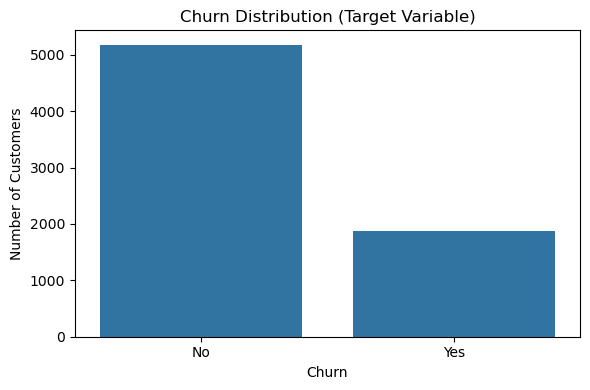

In [48]:
fig, ax = plt.subplots(figsize=(6, 4))

churn_counts = df['Churn'].value_counts()
sns.countplot(data=df, x='Churn', ax=ax)

# Add counts + percentages on top of bars
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.text(p.get_x() + p.get_width()/2, count + 50,
            f'{count}\n({pct:.1f}%)', ha='center', fontsize=11)

ax.set_title('Churn Distribution (Target Variable)')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()

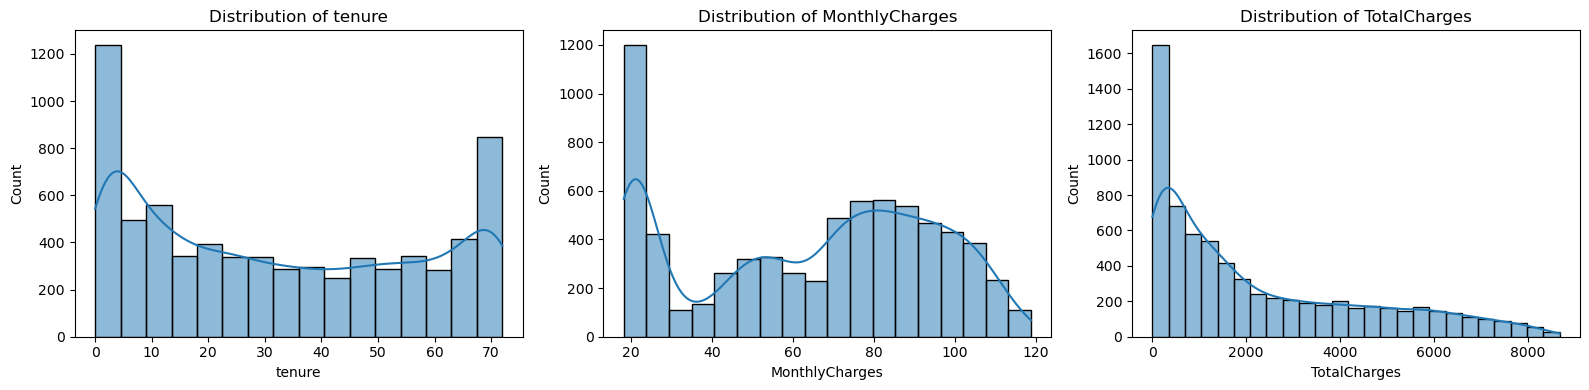

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

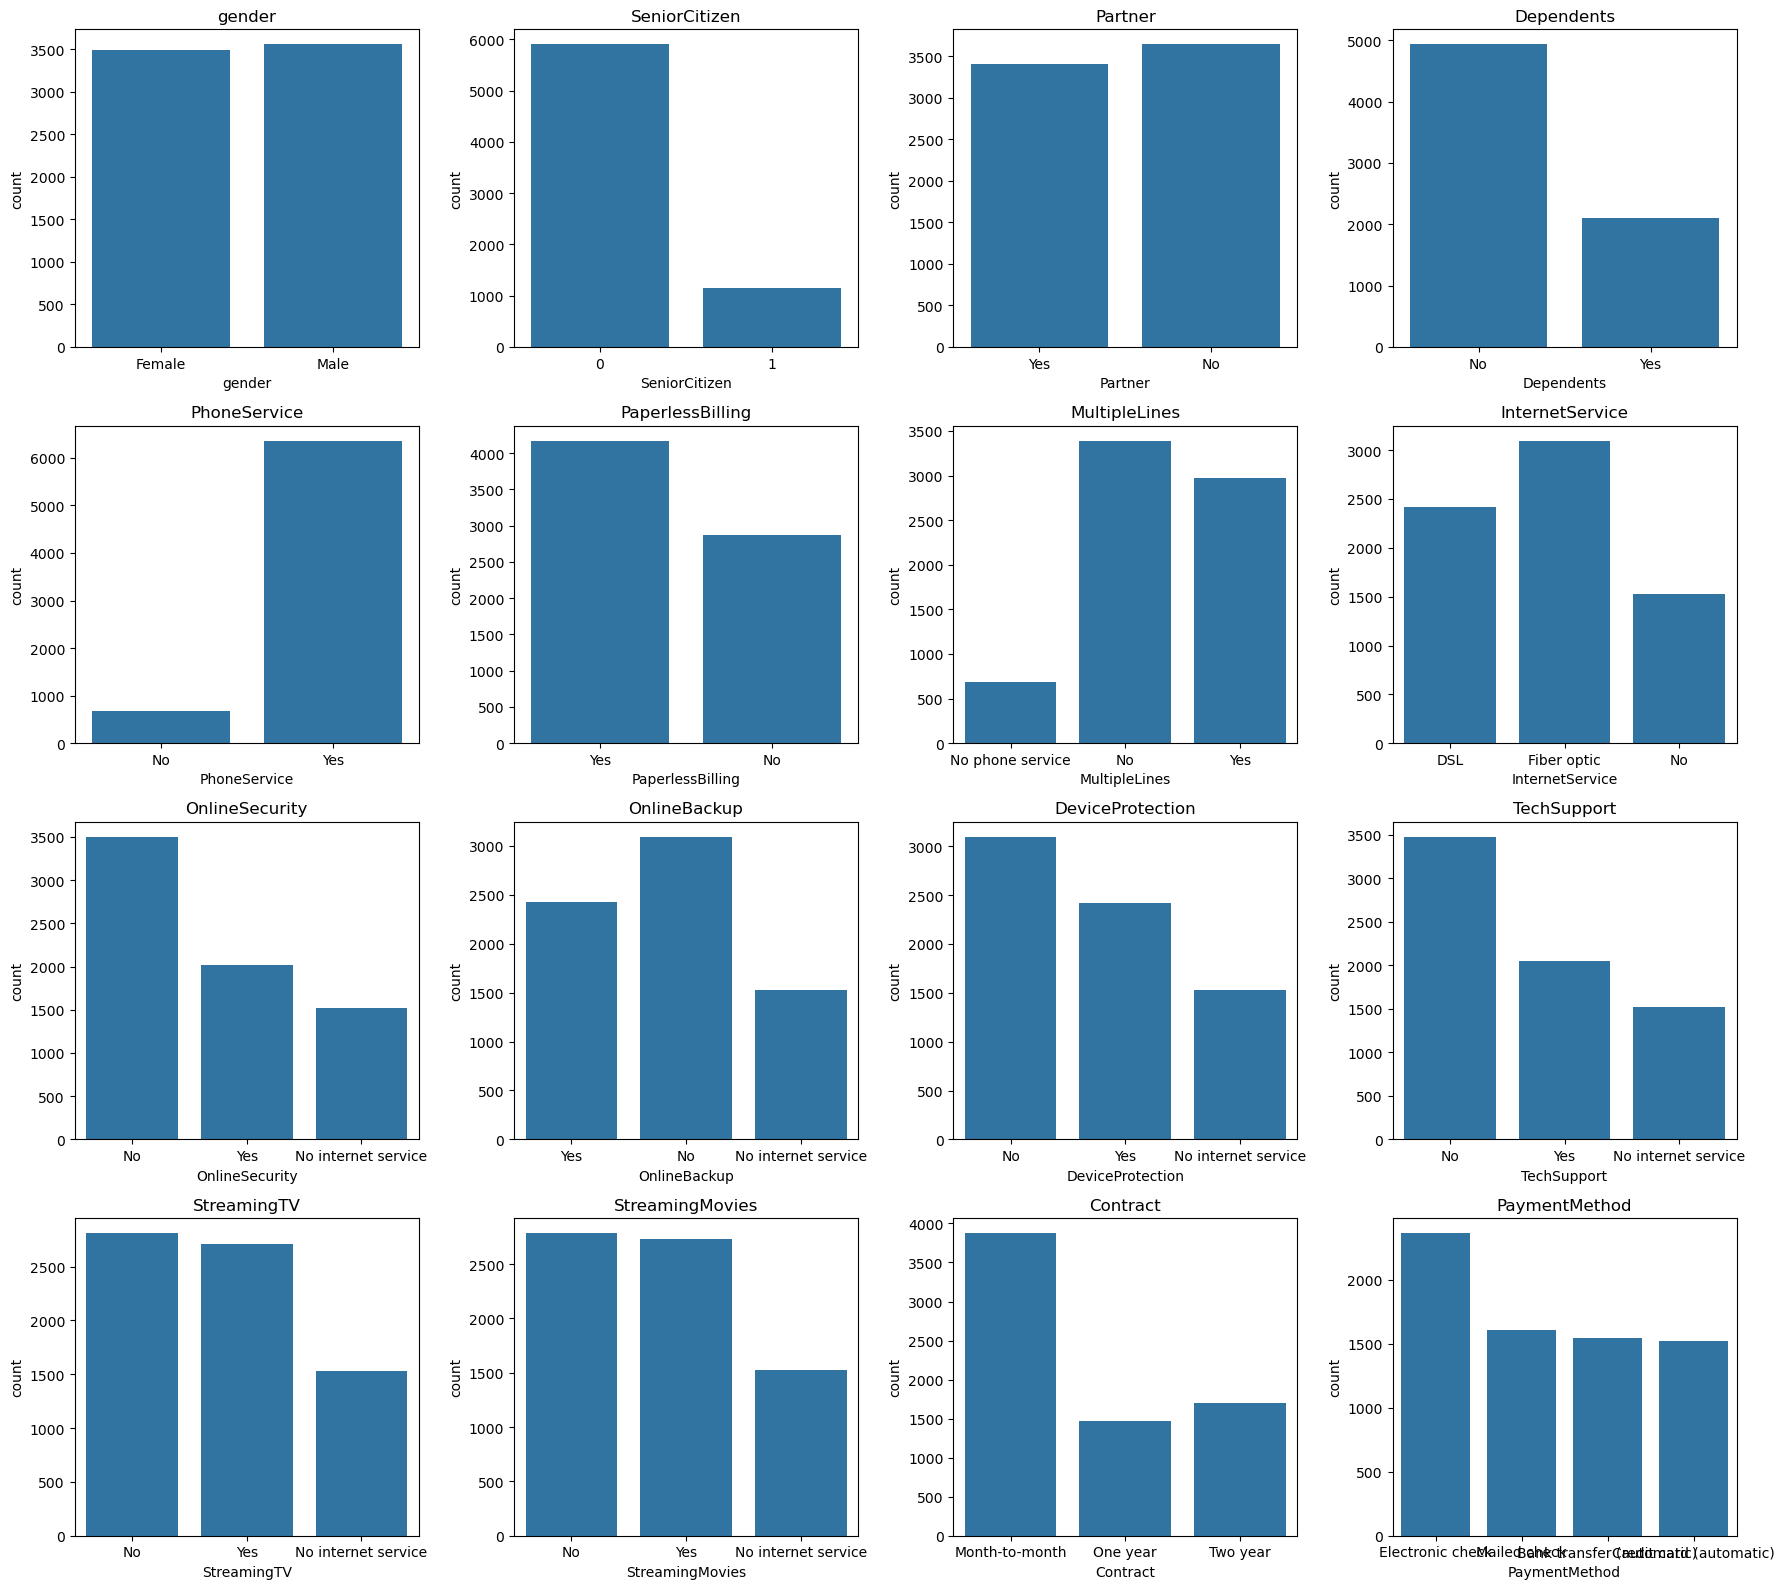

In [59]:
import math

n = len(cols_to_plot)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=0)

# Hide unused axes
for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

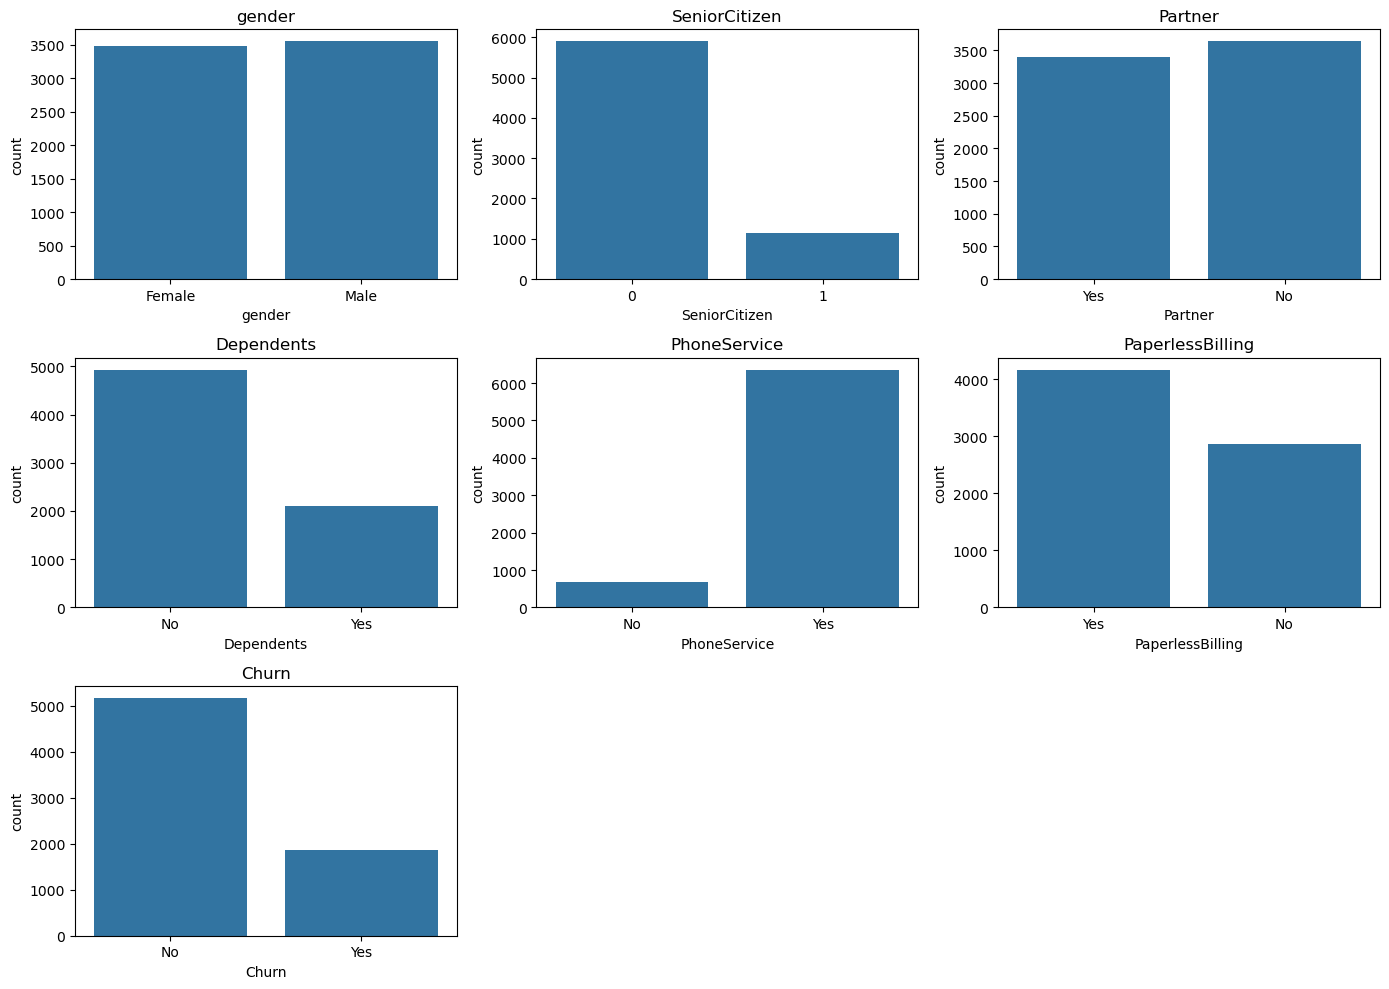

In [64]:

cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
        'PhoneService', 'PaperlessBilling', 'Churn']   # 7 items

fig, axes = plt.subplots(3, 3, figsize=(14, 10))   # 9 slots
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)
for j in range(len(cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()